# 1. Prices are probabilities (almost)

**What this notebook answers:** a prediction-market price looks like a probability. When can we
trust that, when can't we, and how do we compare two venues that describe the same event in
different ways?

**The data:** real quotes for the **October 2026 Federal Reserve meeting**, recorded from
Polymarket and Kalshi and saved in `tests/fixtures/` so this notebook gives the same answer every time.
The question both venues are answering is: *what will the Fed do with interest rates?*

Every formula is explained in plain English first, then shown in code.

In [1]:
import sys
sys.path.insert(0, ".")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import _style as st
from pmq.pricing import clean, coherence, fees, arb

st.setup()
poly, kal, rules = st.load_fomc()

## 1.1 What a contract is

A prediction-market contract is a bet that pays **$1 if the event happens and $0 if it does not**.
If you buy one for $0.40, you risk 40 cents to win 60 cents.

Suppose you believe the true chance of the event is $p$ and the price is $c$. Your average profit
per contract is

$$\text{expected profit} = p\,(1 - c) - (1 - p)\,c = p - c .$$

So **you only expect to make money when your probability is higher than the price.** That is the
whole reason a price can be read as "the market's probability": if enough people thought the
event was more likely than the price says, they would buy, and the price would rise until the
edge disappeared.

Three things make the price an *imperfect* probability, and the rest of this notebook deals with them:

1. **Which number is "the price"?** There is a bid (what buyers offer), an ask (what sellers want) and a last trade that may be hours old.
2. **The prices of all outcomes usually add up to more than 100%.** That extra is the venue's cushion.
3. **Two venues can phrase the same question differently**, so their prices are not directly comparable until we translate one into the other.

## 1.2 Polymarket: one contract per outcome

Polymarket lists five contracts for the October meeting, one for each thing the Fed might do.
Exactly one will happen, so the five "Yes" prices *should* add to $1.00.

**Which price to use.** We use the **middle of the bid and ask** when they are close together,
because it is a better guess at fair value than a stale last trade. If the gap is wider than
10 cents we fall back to the last trade. (`clean.mid_price`)

In [2]:
poly_view = poly.rename(columns={"bps": "change in Fed rate (bps)"})
poly_view[["change in Fed rate (bps)", "label", "bid", "ask", "mid"]]

,change in Fed rate (bps),label,bid,ask,mid
0,-50,50+ bps decrease,0.003,0.004,0.0035
1,-25,25 bps decrease,0.005,0.006,0.0055
2,0,No change,0.430,0.440,0.4350
3,25,25 bps increase,0.550,0.560,0.5550
4,50,50+ bps increase,0.008,0.009,0.0085


In [3]:
total = poly["mid"].sum()
print(f"The five 'Yes' mid prices add up to {total:.4f}")
print(f"Overround (the extra above 100%): {clean.overround(poly['mid']) * 100:.2f} percentage points")

The five 'Yes' mid prices add up to 1.0075
Overround (the extra above 100%): 0.75 percentage points


### The overround, and who "owns" it

The prices add to slightly more than 100%. To turn them into probabilities that add to exactly
100% we have to take that excess out, and the **method matters** because different methods take it out of different places.

**Proportional.** Divide every price by the total. Simple, but it removes the same *percentage*
from every outcome.

$$p_i = \frac{q_i}{\sum_j q_j}$$

**Power.** Raise every price to a power $k$ chosen so they add to 1: $\sum_i q_i^{\,k} = 1$.
Prices are below 1, so a bigger $k$ shrinks small prices by a larger *proportion*. This pushes most
of the correction onto longshots. That matches a well-known habit of bettors: they over-pay for
longshots, so longshots are where the excess tends to live (the *favourite–longshot bias*).

**Shin.** Assume a fraction $z$ of the money comes from insiders who know the answer. Market
makers protect themselves by widening prices. Solve for the $z$ that explains the excess:

$$p_i = \frac{\sqrt{z^2 + 4(1-z)\,q_i^2 / S} - z}{2(1-z)}, \qquad S = \sum_j q_j .$$

Like the power method it takes more from longshots, but it comes with an economic story.

The October Polymarket excess is small (under 1 point), so the methods barely differ there.
To *see* the difference we use a textbook example with a 6% excess.

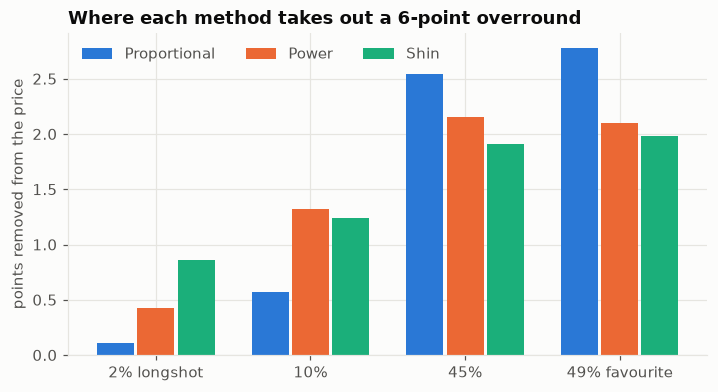

{'Proportional': [0.0189, 0.0943, 0.4245, 0.4623], 'Power': [0.0157, 0.0868, 0.4285, 0.469], 'Shin': [0.0114, 0.0876, 0.4309, 0.4701]}


In [4]:
demo = np.array([0.02, 0.10, 0.45, 0.49])          # adds to 1.06
labels = ["2% longshot", "10%", "45%", "49% favourite"]
methods = {
    "Proportional": clean.normalise_proportional(demo),
    "Power": clean.normalise_power(demo),
    "Shin": clean.normalise_shin(demo),
}
removed = {name: (demo - p) * 100 for name, p in methods.items()}   # percentage points taken off

fig, ax = plt.subplots()
x = np.arange(len(demo)); w = 0.26
for i, (name, colour) in enumerate(zip(removed, [st.BLUE, st.ORANGE, st.AQUA])):
    ax.bar(x + (i - 1) * w, removed[name], w * 0.92, label=name, color=colour)
ax.set_xticks(x, labels)
ax.set_ylabel("points removed from the price")
ax.set_title("Where each method takes out a 6-point overround")
ax.legend(ncol=3, loc="upper left")
plt.show()
print({k: v.round(4).tolist() for k, v in methods.items()})

**How to read it.** The proportional method takes the most from the favourite in *absolute* terms
(because it is the biggest price) but the least in proportion. Power and Shin take proportionally
more from the 2% longshot. None of the three is "the truth"; they are different assumptions about
who pays for the venue's cushion. Later, once we have resolved markets, we can *test* which
assumption predicts outcomes best. Until then we keep all three.

Now the real October numbers:

In [5]:
q = poly["mid"].to_numpy()
out = pd.DataFrame({
    "outcome": poly["label"],
    "raw mid": q,
    "proportional": clean.normalise_proportional(q),
    "power": clean.normalise_power(q),
    "shin": clean.normalise_shin(q),
}).set_index("outcome")
(out * 100).round(2)

,raw mid,proportional,power,shin
outcome,,,,
50+ bps decrease,0.35,0.35,0.33,0.26
25 bps decrease,0.55,0.55,0.52,0.46
No change,43.50,43.18,43.15,43.28
25 bps increase,55.50,55.09,55.18,55.25
50+ bps increase,0.85,0.84,0.81,0.75


## 1.3 Kalshi: a ladder instead of buckets

Kalshi does not list "hike 25" or "no change". It lists a **ladder** of questions of the form
*"will the Fed's upper rate bound end above X%?"* for X = 2.75, 3.00, 3.25 and so on.

Write $S(x)$ for the price of the rung at $x$, i.e. $P(\text{new upper bound} > x)$.
A higher bar is harder to clear, so **$S(x)$ must fall as $x$ rises**. Let's look at the real ladder.
The vertical lines show the gap between bid and ask; the dots are the mid prices.

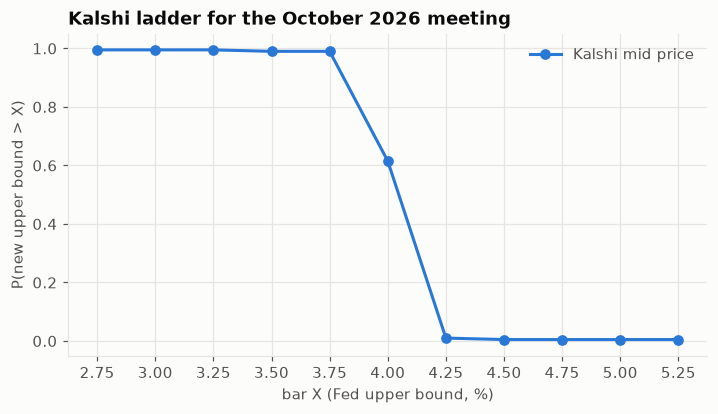

Rungs priced above the rung below them (violations): 0


In [6]:
fig, ax = plt.subplots()
ax.vlines(kal["strike"], kal["bid"], kal["ask"], color=st.GREY, lw=3, zorder=2)
ax.plot(kal["strike"], kal["mid"], "o-", color=st.BLUE, zorder=3, label="Kalshi mid price")
ax.set_xlabel("bar X (Fed upper bound, %)"); ax.set_ylabel("P(new upper bound > X)")
ax.set_title("Kalshi ladder for the October 2026 meeting")
ax.set_xticks(kal["strike"])
ax.legend(loc="upper right")
plt.show()
print("Rungs priced above the rung below them (violations):", coherence.ladder_violations(kal["mid"]))

### Repairing a broken ladder

Real ladders sometimes break the rule (a thin, stale rung priced above the one before it). If we
subtract neighbouring rungs to get buckets, a violation produces a **negative probability**, which
is nonsense.

The fix is the *smallest possible change* that restores the rule: **isotonic regression**. In plain
English: walk along the ladder; whenever a rung is higher than the one before it, replace the two
by their average, and keep merging backwards until nothing goes up. (`coherence.isotonic_decreasing`)

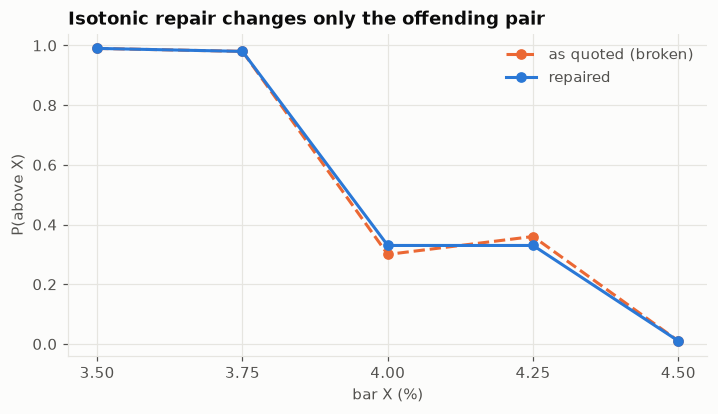

quoted  : [0.99 0.98 0.3  0.36 0.01]
repaired: [0.99 0.98 0.33 0.33 0.01]


In [7]:
stale = np.array([0.99, 0.98, 0.30, 0.36, 0.01])      # the 4th rung is wrongly higher than the 3rd
fixed = coherence.isotonic_decreasing(stale)
x = np.arange(len(stale))
fig, ax = plt.subplots()
ax.plot(x, stale, "o--", color=st.ORANGE, label="as quoted (broken)")
ax.plot(x, fixed, "o-", color=st.BLUE, label="repaired")
ax.set_xticks(x, ["3.50", "3.75", "4.00", "4.25", "4.50"]); ax.set_xlabel("bar X (%)")
ax.set_ylabel("P(above X)"); ax.set_title("Isotonic repair changes only the offending pair")
ax.legend()
plt.show()
print("quoted  :", stale); print("repaired:", fixed.round(3))

## 1.4 Translating the ladder into buckets

The Fed moves in quarter-point steps, so the chance the upper bound ends *exactly* at $x$ is the
gap between two neighbouring rungs:

$$P(\text{new bound} = x) = S(x - 0.25) - S(x)$$

The two ends are special: $P(\text{bound} \le x) = 1 - S(x)$ for the bottom bucket ("cut 50 or more")
and $P(\text{bound} \ge x) = S(x - 0.25)$ for the top bucket ("hike 50 or more").
(`coherence.ladder_to_buckets`)

**One missing piece.** Buckets are measured as *changes* ("hike 25"), so we need to know where the
Fed's upper bound is **before** the meeting. Neither venue's data says. The clean answer is the
Fed's own series (FRED code `DFEDTARU`), which we will plug in once the FRED key arrives.

Until then we can do something honest and instructive: **ask which starting level makes the two
venues agree best.** If we guess the wrong starting point, the buckets slide out of alignment and the
disagreement is large.

In [8]:
ladder = dict(zip(kal["strike"], kal["mid"]))
poly_p = pd.Series(clean.normalise_shin(poly["mid"]), index=poly["bps"])

rows = []
for start in np.arange(3.50, 4.51, 0.25):
    try:
        b = coherence.ladder_to_buckets(ladder, start)
    except KeyError:
        continue
    gap = sum(abs(b[k] - poly_p[k]) for k in b)
    rows.append({"assumed current upper bound (%)": round(start, 2), "total disagreement (points)": gap * 100})
scan = pd.DataFrame(rows).set_index("assumed current upper bound (%)")
scan.round(1)

,total disagreement (points)
assumed current upper bound (%),
3.50,197.0
3.75,122.1
4.00,12.5
4.25,110.0
4.50,196.6


The disagreement is smallest at **4.00%**, so we use that as a stand-in. This is a consistency
check, not a fact: it will be replaced by the Fed's published number. Now the buckets side by side:

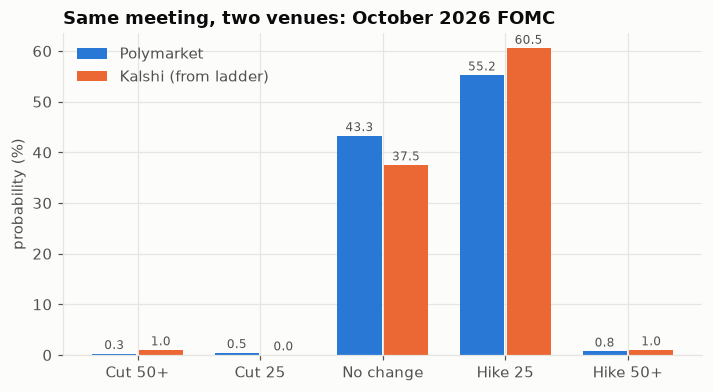

,Polymarket (Shin),Kalshi ladder,gap (Kalshi - Polymarket)
-50,0.26,1.0,0.74
-25,0.46,0.0,-0.46
0,43.28,37.5,-5.78
25,55.25,60.5,5.25
50,0.75,1.0,0.25


In [9]:
START = 4.00
kal_b = pd.Series(coherence.ladder_to_buckets(ladder, START))
cmp = pd.DataFrame({"Polymarket (Shin)": poly_p, "Kalshi ladder": kal_b}) * 100
cmp["gap (Kalshi - Polymarket)"] = cmp["Kalshi ladder"] - cmp["Polymarket (Shin)"]
names = {-50: "Cut 50+", -25: "Cut 25", 0: "No change", 25: "Hike 25", 50: "Hike 50+"}

fig, ax = plt.subplots()
x = np.arange(len(cmp)); w = 0.38
b1 = ax.bar(x - w/2, cmp["Polymarket (Shin)"], w * 0.95, color=st.BLUE, label="Polymarket")
b2 = ax.bar(x + w/2, cmp["Kalshi ladder"], w * 0.95, color=st.ORANGE, label="Kalshi (from ladder)")
for bars in (b1, b2):
    for r in bars:
        ax.annotate(f"{r.get_height():.1f}", (r.get_x() + r.get_width()/2, r.get_height()),
                    xytext=(0, 3), textcoords="offset points", ha="center", fontsize=8, color=st.INK_SOFT)
ax.set_xticks(x, [names[i] for i in cmp.index]); ax.set_ylabel("probability (%)")
ax.set_title("Same meeting, two venues: October 2026 FOMC"); ax.legend()
plt.show()
cmp.round(2)

**Reading it.** The venues largely agree on the shape of the outcome. The gaps are 5-6 points on
the two big buckets. (Ignore the tiny 0-1% tail buckets on the Kalshi side: Kalshi prices in whole
cents, so a rung quoted at 99 cents next to one at 98 cents leaves a rounding remainder.)
Before calling the big gaps a trade, three cautions:

* **The rules may differ.** Kalshi resolves on the *upper bound after the meeting*; Polymarket resolves on the *change in basis points* and rounds odd moves up to the nearest 25. Below are both rule texts.
* **The Kalshi numbers are built from two rungs each**, so their bid–ask spreads compound.
* **Fees.** A gap has to survive fees on both legs (next section).

In [10]:
print("POLYMARKET:", rules["polymarket"], "\n")
print("KALSHI    :", rules["kalshi"])

POLYMARKET: The FED interest rates are defined in this market by the upper bound of the target federal funds range. The decisions on the target federal funds range are made by the Federal Open Market Committee (FOMC) meetings. 

KALSHI    : If the upper bound of the target federal funds rate published on the Federal Reserve's official website is greater than 2.75% following the Federal Reserve's Oct 28, 2026 meeting, then the market resolves to Yes.


## 1.5 Does a gap survive fees?

Both venues charge takers a fee that is biggest for 50/50 contracts and vanishes at the extremes:

$$\text{fee per contract} = r \cdot \big(p\,(1-p)\big)^{e}$$

At $p = 0.50$ with Kalshi's rate $r = 0.07$ that is 1.75 cents on a contract worth $1. If the gap
between two venues is 3 cents, fees on both legs can easily eat most of it. **Every edge in this
project is quoted after fees.** (Rates change over time; treat the defaults as configuration to verify.)

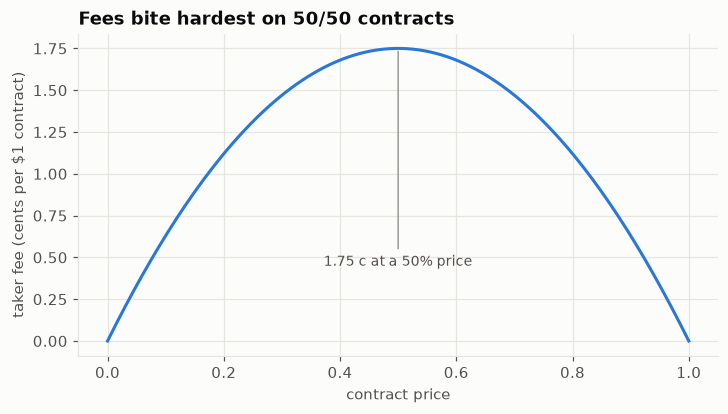

Buy at 45c, sell at 47c: gross 2c, after fees on both legs -1.48c
Buy at 45c, sell at 50c: gross 5c, after fees on both legs 1.52c


In [11]:
p = np.linspace(0, 1, 201)
fig, ax = plt.subplots()
ax.plot(p, [fees.taker_fee(x) * 100 for x in p], color=st.BLUE)
ax.set_xlabel("contract price"); ax.set_ylabel("taker fee (cents per $1 contract)")
ax.set_title("Fees bite hardest on 50/50 contracts")
ax.annotate("1.75 c at a 50% price", (0.5, 1.75), xytext=(0.5, 0.45), ha="center", fontsize=9, color=st.INK_SOFT,
            arrowprops={"arrowstyle": "-", "color": st.GREY})
plt.show()

for gap in (0.02, 0.05):
    net = arb.cross_venue_edge(ask_cheap=0.45, bid_dear=0.45 + gap)
    print(f"Buy at 45c, sell at {45 + gap * 100:.0f}c: gross {gap * 100:.0f}c, after fees on both legs {net * 100:.2f}c")

**Dutch book on one venue.** If one venue's asks for every outcome add to less than $1.00, buying
one of each guarantees a profit whatever happens. Check the real October Polymarket asks:

In [12]:
asks = poly["ask"].to_numpy(); bids = poly["bid"].to_numpy()
print(f"Sum of asks {asks.sum():.4f}  ->  profit from buying every outcome (fees ignored): {arb.dutch_book_buy_all(asks, rate=0.0) * 100:.2f} c")
print(f"Sum of bids {bids.sum():.4f}  ->  profit from selling every outcome, fees ignored: {arb.dutch_book_sell_all(bids, rate=0.0) * 100:.2f} c")

Sum of asks 1.0190  ->  profit from buying every outcome (fees ignored): -1.90 c
Sum of bids 0.9960  ->  profit from selling every outcome, fees ignored: -0.40 c


A negative number means no free lunch: the venue's own cushion (the overround) is bigger than the
gap you would need. Liquid markets almost always look like this. Real opportunities, when they
appear, are short-lived and small, which is why the pipeline records order-book snapshots
continuously rather than looking once.

## 1.6 How the price moved

The recorded daily history of the "No change" contract, from the market's creation to the
snapshot. Prices in these markets trend as data arrives, and the trend is what the Bayesian model
in notebook 2 tries to explain.

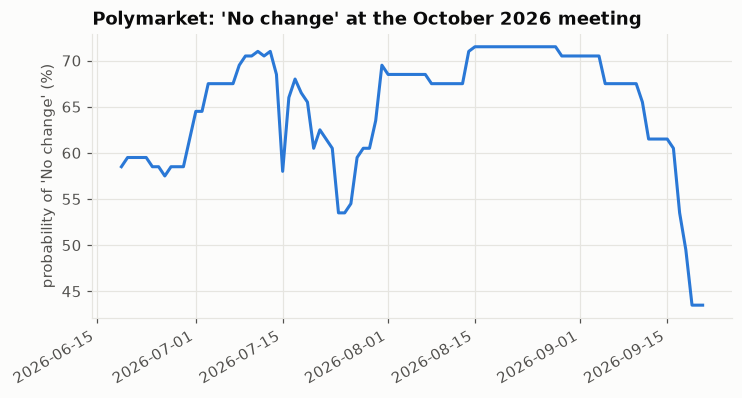

In [13]:
hist = st.load_price_history()
fig, ax = plt.subplots()
ax.plot(hist.index, hist.values * 100, color=st.BLUE)
ax.set_ylabel("probability of 'No change' (%)"); ax.set_title("Polymarket: 'No change' at the October 2026 meeting")
fig.autofmt_xdate()
plt.show()

## Recap

* A price is a probability only after you choose *which* price (mid, not last) and remove the venue's cushion (three defensible methods).
* Ladders must fall as the bar rises. If a quote breaks that, repair it with the smallest change before differencing.
* Differencing rungs converts a Kalshi ladder into Polymarket-style buckets, provided you know the starting rate.
* A gap between venues is only a trade if it survives **fees**, **spreads** and **rule differences**.

**Next:** notebook 2 asks how a *model* should update its beliefs as evidence arrives, and how to
combine it sensibly with the market price.